**Import**

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix , classification_report, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

**1.1** ***Load and Explore***

check the shape and missings. drop columns that it is not importanat or benefit us in prediction .fill one column. Check class balance . label encoding  .

In [21]:
df= pd.read_csv('/content/train.csv')
print(df.head(10))

#shape
df_shape = df.shape
print(df_shape) #there are 891 rows and 12 columns

#missing
missing = df.isnull().sum() # The sum of the missing values in each column .
print(missing , '\n the age column is most column that has missing values')

#drop columns that it is not importanat or benefit us in prediction
df.drop('Cabin',axis=1,inplace=True)#i took this way in dropping from منصة سطر(PANDAS COURCE) .
df.drop('Ticket',axis=1,inplace=True)
df.drop('Name',axis=1,inplace=True)
df.drop('Embarked',axis=1,inplace=True)

# filling because the missing values are few .
df["Age"] = df["Age"].fillna(df["Age"].mean())

#Check class balance
print(df['Survived'].value_counts())#it is balanced data because the numbers are similer

# label encoding to the Sex column.
encoding = LabelEncoder()
df['Sex_encode']= encoding.fit_transform(df['Sex'])
df.drop('Sex',axis=1,inplace=True)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy J    male  54

**1.2** . ***Prepare the Data***.

split the features to X and y . Split into train and test sets (80/20)


In [22]:
features =['PassengerId','Pclass','Age','SibSp','Parch','Fare','Sex_encode']
X = df[features]
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


**1.2** . ***Train and Compare Models***.

train three models(LogisticRegression,RandomForest,KNN).and output accuracy, precision, recall, F1-score for each model in a table. Plot a confusion matrix for each model . choosing the best model

                model  accuracy  precision    recall        f1
0  LogisticRegression  0.804469   0.783333  0.681159  0.728682
1        RandomForest  0.787709   0.746032  0.681159  0.712121
2                 KNN  0.659218   0.681818  0.217391  0.329670
the best model name: LogisticRegression
i choose the model that has the highest f1-score to be the best model. 
 because the f1-score combines recall and precision. 
 and i want both precision and recall


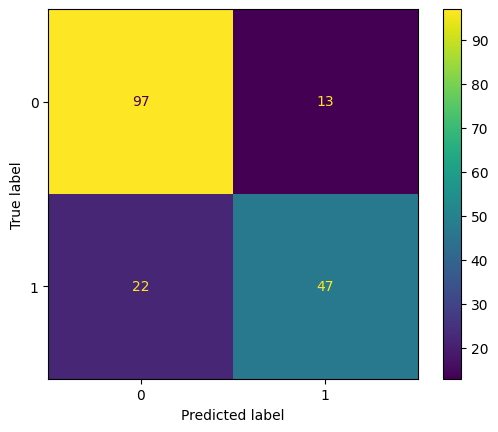

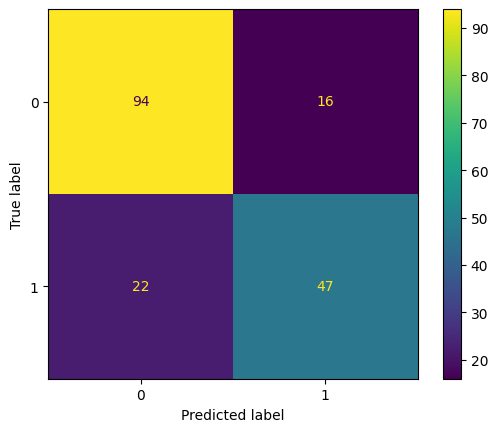

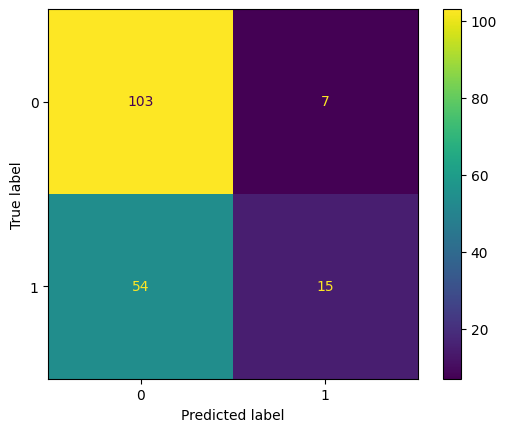

In [23]:
models = [['LogisticRegression',LogisticRegression(max_iter=10000)],
 ['RandomForest', RandomForestClassifier(n_estimators=100,random_state=42)],['KNN',KNeighborsClassifier(n_neighbors=29)]]
results = []
conf = []
for name, model in models:
  model.fit(X_train, y_train)
  predictions = model.predict(X_test)
  #metrics
  acc= accuracy_score(y_test,predictions)
  prec = precision_score(y_test, predictions, zero_division=0)
  recall = recall_score(y_test, predictions, zero_division=0)
  f1 = f1_score(y_test, predictions, zero_division=0)
  results.append([name,acc,prec,recall,f1])
  #confusion matrix
  cm = confusion_matrix(y_test, predictions)
  conf.append(cm)# add the confusion matrix in the conf list


# results in a table .
df_results = pd.DataFrame(results,columns = ['model','accuracy','precision','recall','f1'])
print(df_results)
best_model = df_results.sort_values('f1',ascending=False).iloc[0]
print('the best model name:',best_model['model'])
print('i choose the model that has the highest f1-score to be the best model.','\n because the f1-score combines recall and precision.','\n and i want both precision and recall')

# plot the confusion matrix
for i in range(3):
  disp =  ConfusionMatrixDisplay(confusion_matrix=conf[i])
  disp.plot()
  plt.show()



# **Neural Network**

**2.1**  ***Build and Train***.

build a neural network using sigmoid , ReLU. adding dropout layer to reduce overfitting. 10 epochs . plot training and validation (accuracy and loss) .

0.6944444179534912


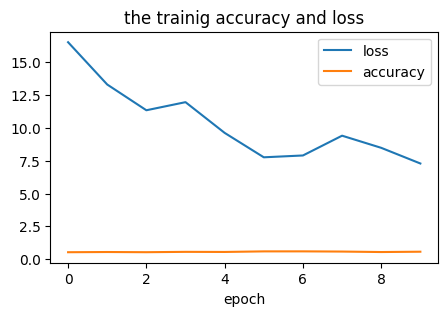

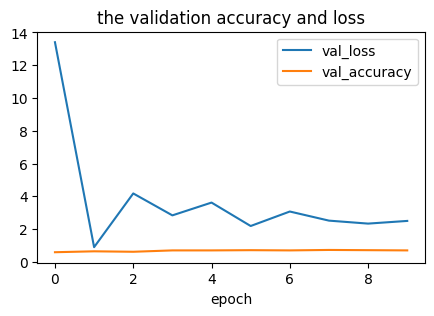

In [24]:
#covert from dataframe to array.
X_train = X_train.values
y_train = y_train.values
X_test = X_test.values
y_test = y_test.values


#the nueral network
model = keras.Sequential([

keras.Input(shape=(7,)),
layers.Dense(128, activation="relu"),
layers.Dropout(0.3),
layers.Dense(1, activation="sigmoid")# because the label is binary .
])
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy",'precision','recall'])
history = model.fit(X_train, y_train,validation_split=0.1, epochs=10, verbose=0)# training.


print(history.history['val_accuracy'][-1])# the validation accuracy for last epoch.


#plotting accuracy and validation for the training and the validation .

#traing
plt.figure(figsize=(5, 3))
plt.plot(history.history['loss'], label = 'loss')
plt.plot(history.history['accuracy'], label = 'accuracy')
plt.title('the trainig accuracy and loss')
plt.xlabel('epoch')
plt.legend()
plt.show()

#validation.
plt.figure(figsize=(5, 3))
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.title('the validation accuracy and loss')
plt.xlabel('epoch')
plt.legend()
plt.show()


# **2.2** ***Compare with Step 1***
evaluate on the test set using the same metrics in the step 1 except the f1-score because i did not how to output it. add the results to the table in step 1.

In [25]:
test_loss, test_acc,test_precision,test_recall = model.evaluate(X_test, y_test,verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

print(f"Test loss: {test_loss:.4f}")

print(f"Test precision: {test_precision:.4f}")

print(f"Test recall: {test_loss:.4f}")

# i did not know how to output the f1

# Make predictions
predictions = model.predict(X_test[:5],verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

#table
results.append(['nueral network 1',test_acc,test_precision,test_recall])
df_results = pd.DataFrame(results,columns = ['model','accuracy','precision','recall','f1'])
print(df_results)
print('according to the table,my nueral network was not better than other models.the reason is that  my nueral network metrics is not hiegher than other models matrics .')#explaing

Test accuracy: 0.6480
Test loss: 2.4301
Test precision: 0.5938
Test recall: 2.4301
                model  accuracy  precision    recall        f1
0  LogisticRegression  0.804469   0.783333  0.681159  0.728682
1        RandomForest  0.787709   0.746032  0.681159  0.712121
2                 KNN  0.659218   0.681818  0.217391  0.329670
3    nueral network 1  0.648045   0.593750  0.275362       NaN
according to the table,my nueral network was not better than other models.the reason is that  my nueral network metrics is not hiegher than other models matrics .


**2.2 Compare with Step 1**

making neural network and make trainig and evaluate on the test set as i made before . just i change the learning rate, to show the difference of results when we change the learning rate .

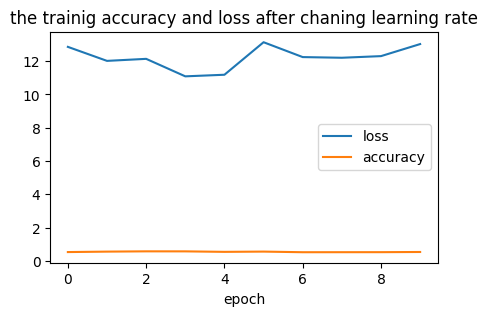

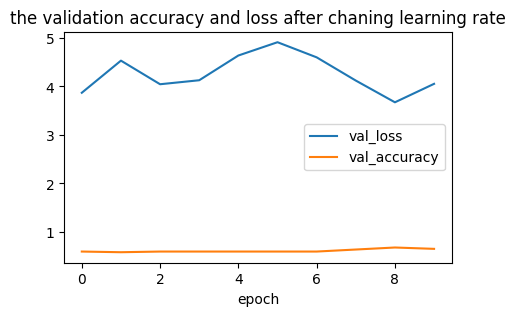

                model  accuracy  precision    recall        f1
0  LogisticRegression  0.804469   0.783333  0.681159  0.728682
1        RandomForest  0.787709   0.746032  0.681159  0.712121
2                 KNN  0.659218   0.681818  0.217391  0.329670
3    nueral network 1  0.648045   0.593750  0.275362       NaN
4    nueral network 2  0.608939   0.466667  0.101449       NaN


In [26]:
model = keras.Sequential([

keras.Input(shape=(7,)),
layers.Dense(128, activation="relu"),
layers.Dropout(0.3),
layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001), loss="binary_crossentropy", metrics=["accuracy",'precision','recall'])
history = model.fit(X_train, y_train,validation_split=0.1, epochs=10, verbose=0)


#plotting
plt.figure(figsize=(5, 3))
plt.plot(history.history['loss'], label = 'loss')
plt.plot(history.history['accuracy'], label = 'accuracy')
plt.title('the trainig accuracy and loss after chaning learning rate')
plt.xlabel('epoch')
plt.legend()
plt.show()
plt.figure(figsize=(5, 3))
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.title('the validation accuracy and loss after chaning learning rate')
plt.xlabel('epoch')
plt.legend()
plt.show()

#evaluate
test_loss, test_acc,test_precision,test_recall = model.evaluate(X_test, y_test,verbose=0)
results.append(['nueral network 2',test_acc,test_precision,test_recall])
df_results = pd.DataFrame(results,columns = ['model','accuracy','precision','recall','f1'])
print(df_results)